# 📊 Experiment0 Post-Analysis: Method Selection for Full Benchmarking

**Objective**: Analyze Experiment0 results to identify the best-performing methods for the full benchmark (Experiment1).

---

## Overview

**Experiment0** is a pilot study designed to:
1. Test all available methods on a subset of datasets
2. Identify high-performing methods worth including in the full benchmark
3. Filter out underperforming or problematic methods
4. Balance performance vs. computational cost

This notebook provides:
- **Performance Analysis**: Heatmaps and rankings for PD and LGD tasks
- **Training Time Analysis**: Computational efficiency of each method
- **Method Selection**: Data-driven recommendations for Experiment1
- **Statistical Testing**: Significance of performance differences

---

## 1. Setup & Configuration

In [1]:
# Standard imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



# Setup paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "results" / "experiment0"
SUMMARY_DIR = RESULTS_DIR / "summary"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print(f"📂 Project root: {PROJECT_ROOT}")
print(f"📂 Results directory: {RESULTS_DIR}")
print(f"📂 Summary directory: {SUMMARY_DIR}")
print(f"📂 Figures directory: {FIGURES_DIR}")

📂 Project root: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit
📂 Results directory: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment0
📂 Summary directory: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment0\summary
📂 Figures directory: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment0\figures


In [2]:
# Plotting configuration
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

# Color schemes
CMAP_PERFORMANCE = 'RdYlGn'  # Red (bad) to Green (good)
CMAP_TIME = 'YlOrRd'  # Yellow (fast) to Red (slow)

## 2. Data Loading

In [3]:
# Load raw and aggregated results
pd_raw = pd.read_csv(SUMMARY_DIR / "summary_pd_raw.csv")
pd_agg = pd.read_csv(SUMMARY_DIR / "summary_pd_aggregated.csv")
lgd_raw = pd.read_csv(SUMMARY_DIR / "summary_lgd_raw.csv")
lgd_agg = pd.read_csv(SUMMARY_DIR / "summary_lgd_aggregated.csv")

print("\n📊 Data Overview:")
print(f"\nPD (Probability of Default):")
print(f"  - Raw results: {len(pd_raw)} fold results")
print(f"  - Methods: {pd_raw['method'].nunique()}")
print(f"  - Datasets: {pd_raw['dataset'].nunique()}")
print(f"  - Methods: {sorted(pd_raw['method'].unique())}")

print(f"\nLGD (Loss Given Default):")
print(f"  - Raw results: {len(lgd_raw)} fold results")
print(f"  - Methods: {lgd_raw['method'].nunique()}")
print(f"  - Datasets: {lgd_raw['dataset'].nunique()}")
print(f"  - Methods: {sorted(lgd_raw['method'].unique())}")


📊 Data Overview:

PD (Probability of Default):
  - Raw results: 1110 fold results
  - Methods: 37
  - Datasets: 15
  - Methods: ['LogReg', 'NCM', 'NaiveBayes', 'RandomForest', 'amformer', 'autoint', 'bishop', 'catboost', 'danets', 'dcn2', 'dummy', 'excelformer', 'ftt', 'grownet', 'knn', 'lightgbm', 'mlp', 'mlp_plr', 'modernNCA', 'node', 'protogate', 'ptarl', 'realmlp', 'resnet', 'snn', 'svm', 'switchtab', 't2gformer', 'tabcaps', 'tabicl', 'tabm', 'tabnet', 'tabpfn', 'tabpfn_v2', 'tabtransformer', 'tangos', 'xgboost']

LGD (Loss Given Default):
  - Raw results: 432 fold results
  - Methods: 31
  - Datasets: 7
  - Methods: ['LinearRegression', 'RandomForest', 'amformer', 'autoint', 'bishop', 'catboost', 'danets', 'dcn2', 'dnnr', 'excelformer', 'ftt', 'grownet', 'knn', 'lightgbm', 'mlp', 'mlp_plr', 'modernNCA', 'node', 'ptarl', 'realmlp', 'resnet', 'snn', 'svm', 'switchtab', 't2gformer', 'tabm', 'tabnet', 'tabpfn_v2', 'tabtransformer', 'tangos', 'xgboost']


## 3. Performance Analysis: PD Task

### 3.1 Performance Heatmaps (Methods × Datasets)

Creating PD AUC heatmap...
✅ Saved: pd_heatmap_auc.png


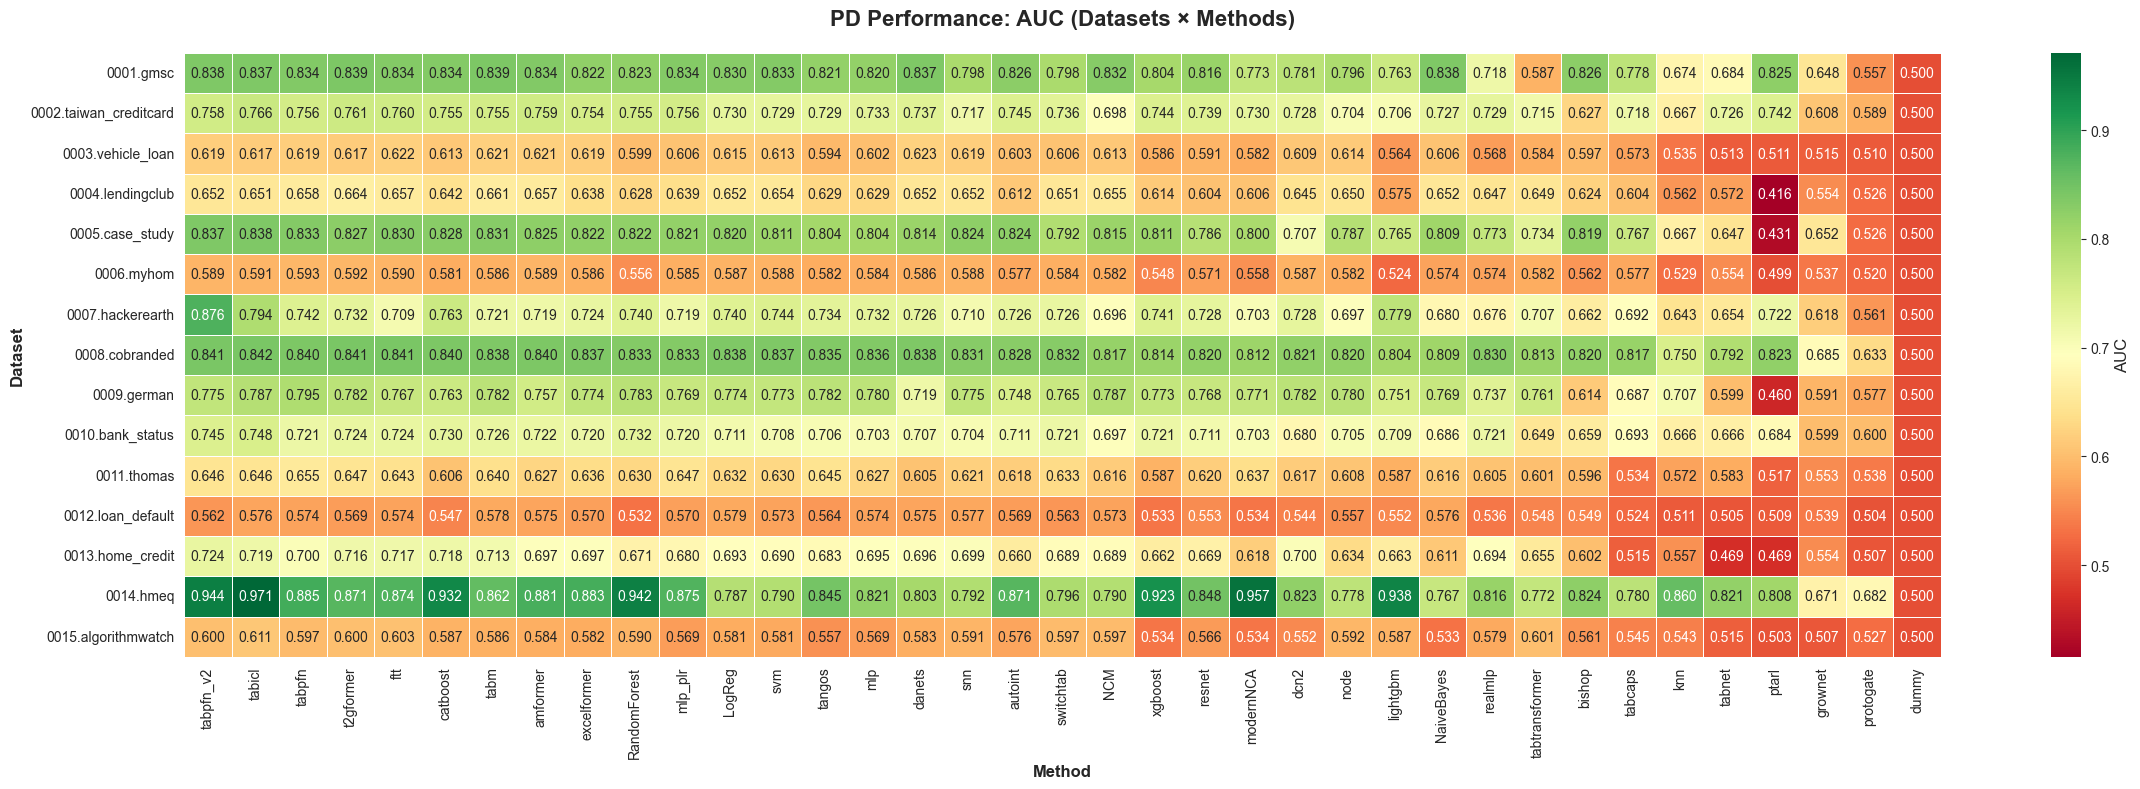

In [26]:
def create_performance_heatmap(df, metric, task_name, cmap='RdYlGn', figsize=(24, 8)):
    """
    Create a heatmap showing method performance across datasets.
    
    Args:
        df: Aggregated dataframe
        metric: Metric to visualize (e.g., 'AUC', 'F1', 'R2')
        task_name: 'PD' or 'LGD'
        cmap: Colormap
        figsize: Figure size
    """
    mean_col = f'{metric}_mean'
    
    if mean_col not in df.columns:
        print(f"⚠️  Metric '{metric}' not found in data")
        return None
    
    # Create pivot table (datasets on rows, methods on columns)
    pivot = df.pivot(index='dataset', columns='method', values=mean_col)
    
    # Sort datasets alphabetically (Y-axis)
    pivot = pivot.sort_index()
    
    # Sort methods by average performance across datasets (X-axis, descending = best first)
    method_means = pivot.mean(axis=0).sort_values(ascending=False)
    pivot = pivot[method_means.index]
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Determine vmin/vmax for consistent color scaling
    vmin = pivot.min().min()
    vmax = pivot.max().max()
    
    # Create heatmap
    sns.heatmap(
        pivot,
        annot=True,
        fmt='.3f',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        cbar_kws={'label': metric},
        linewidths=0.5,
        ax=ax
    )
    
    ax.set_title(f'{task_name} Performance: {metric} (Datasets × Methods)', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Method', fontsize=12, fontweight='bold')
    ax.set_ylabel('Dataset', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    
    # Save figure
    filename = FIGURES_DIR / f"{task_name.lower()}_heatmap_{metric.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {filename.name}")
    
    return fig, pivot


# PD: AUC Heatmap
print("Creating PD AUC heatmap...")
fig_pd_auc, pivot_pd_auc = create_performance_heatmap(
    pd_agg, 'AUC', 'PD', cmap='RdYlGn'
)
plt.show()

Creating PD F1 heatmap...
✅ Saved: pd_heatmap_f1.png


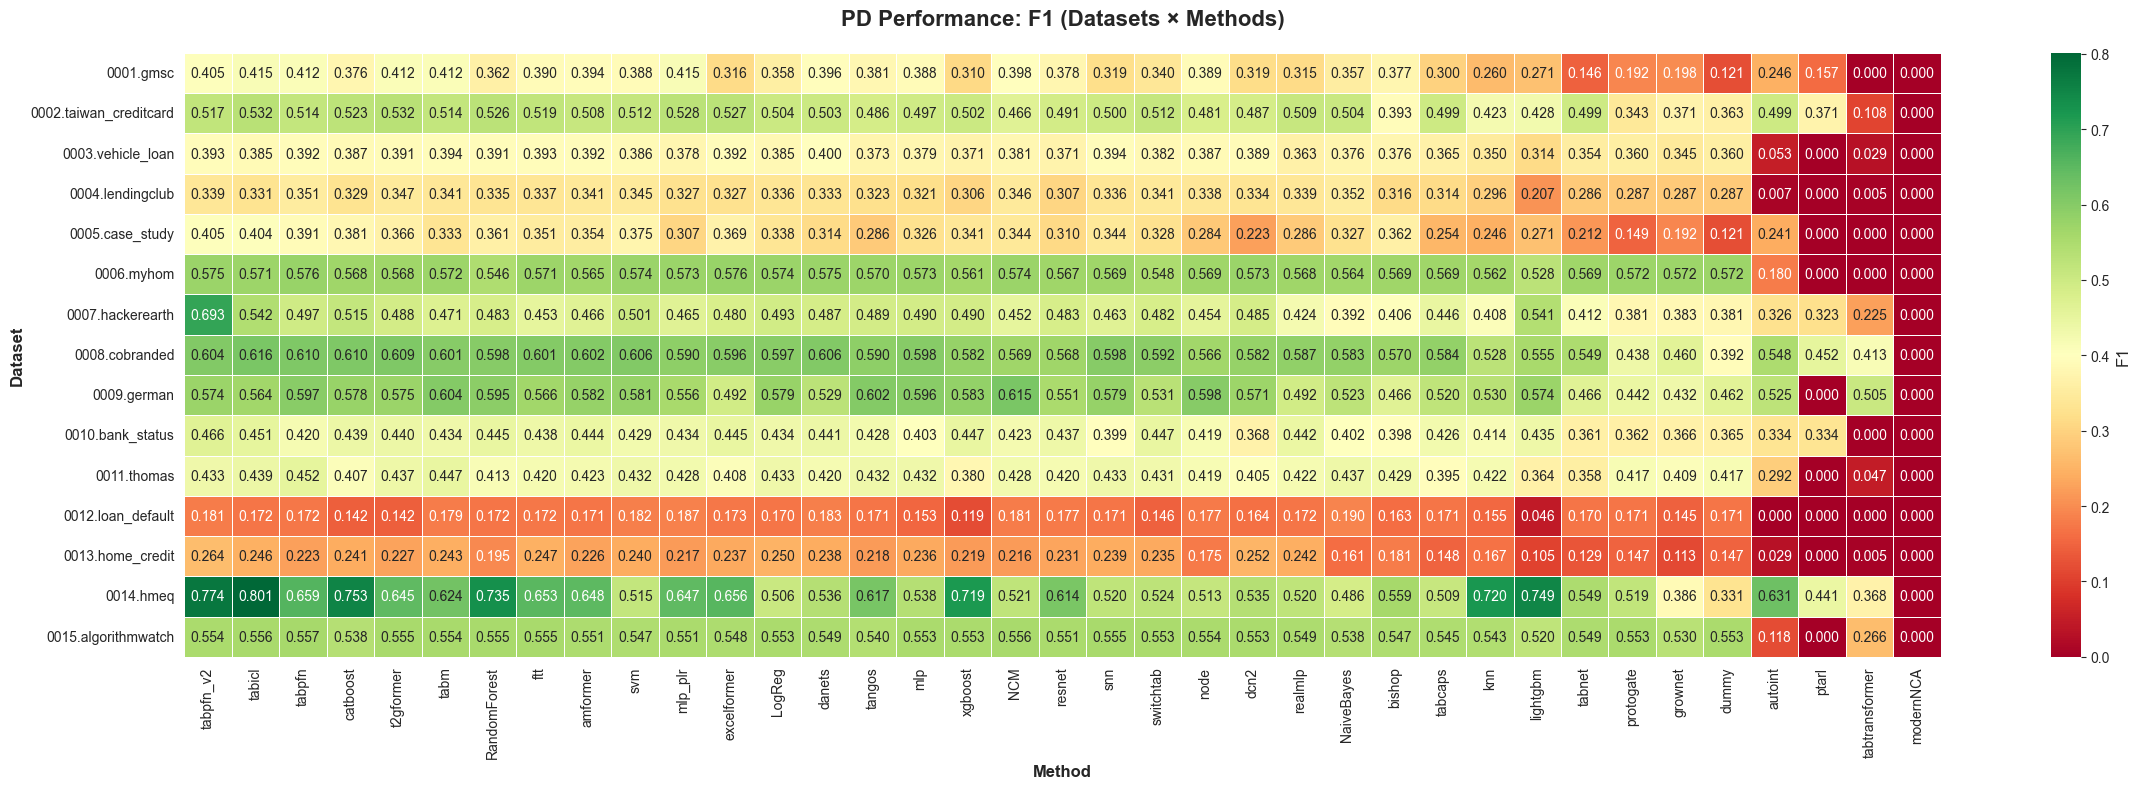

In [27]:
# PD: F1 Heatmap
print("Creating PD F1 heatmap...")
fig_pd_f1, pivot_pd_f1 = create_performance_heatmap(
    pd_agg, 'F1', 'PD', cmap='RdYlGn'
)
plt.show()

### 3.2 Method Rankings (PD)

Creating PD AUC rank heatmap...
✅ Saved: pd_heatmap_rank_auc.png


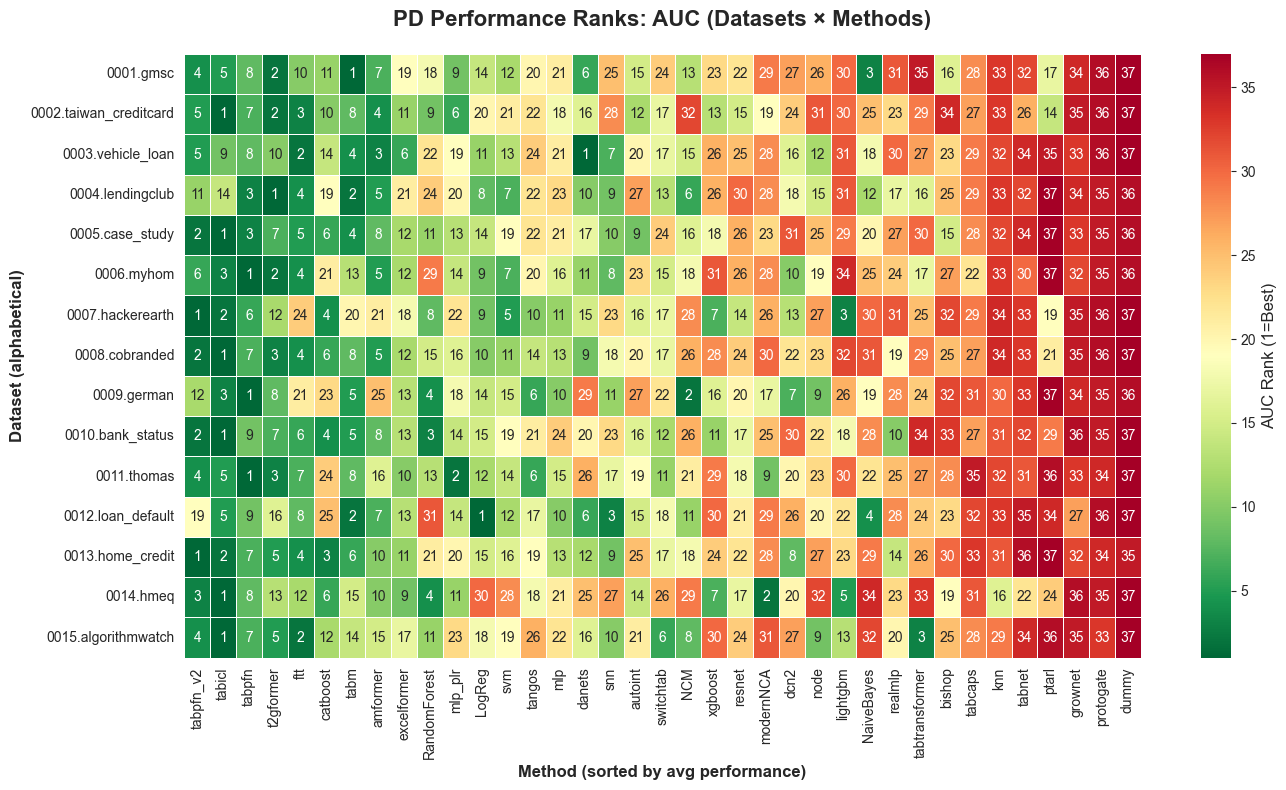

In [33]:
def create_performance_rank_heatmap(df, metric, task_name, cmap='RdYlGn_r', figsize=(14, 8)):
    """
    Create a heatmap showing method RANKS across datasets.
    
    Rank 1 = best performing method on that dataset
    Rank N = worst performing method on that dataset
    
    Args:
        df: Aggregated dataframe
        metric: Metric to visualize (e.g., 'AUC', 'F1', 'R2')
        task_name: 'PD' or 'LGD'
        cmap: Colormap (reversed: RdYlGn_r means green=rank 1, red=high rank)
        figsize: Figure size
    """
    mean_col = f'{metric}_mean'
    
    if mean_col not in df.columns:
        print(f"⚠️  Metric '{metric}' not found in data")
        return None
    
    # Create pivot table (datasets on rows, methods on columns)
    pivot = df.pivot(index='dataset', columns='method', values=mean_col)
    
    # Sort datasets alphabetically (Y-axis)
    pivot = pivot.sort_index()
    
    # Calculate ranks per dataset (row-wise)
    # rank(ascending=False) means higher values get lower ranks (1 = best)
    # method='min' means ties get the same rank
    pivot_ranks = pivot.rank(axis=1, ascending=False, method='min')
    
    # Sort methods by average performance across datasets (X-axis)
    method_means = pivot.mean(axis=0).sort_values(ascending=False)
    pivot_ranks = pivot_ranks[method_means.index]
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(
        pivot_ranks,
        annot=True,
        fmt='.0f',  # Integer format for ranks
        cmap=cmap,  # Reversed colormap (green=rank 1, red=high ranks)
        vmin=1,
        vmax=pivot_ranks.max().max(),
        cbar_kws={'label': f'{metric} Rank (1=Best)'},
        linewidths=0.5,
        ax=ax
    )
    
    ax.set_title(f'{task_name} Performance Ranks: {metric} (Datasets × Methods)', 
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Method (sorted by avg performance)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Dataset (alphabetical)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    
    # Save figure
    filename = FIGURES_DIR / f"{task_name.lower()}_heatmap_rank_{metric.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {filename.name}")
    
    return fig, pivot_ranks


# PD: AUC Rank Heatmap
print("Creating PD AUC rank heatmap...")
fig_pd_auc_rank, pivot_pd_auc_rank = create_performance_rank_heatmap(
    pd_agg, 'AUC', 'PD', cmap='RdYlGn_r'
)
plt.show()

In [28]:
def create_method_ranking(df, metrics, task_name):
    """
    Create a ranking table for methods across multiple metrics.
    
    Args:
        df: Aggregated dataframe
        metrics: List of metrics to include
        task_name: 'PD' or 'LGD'
    """
    rankings = []
    
    for metric in metrics:
        mean_col = f'{metric}_mean'
        std_col = f'{metric}_std'
        
        if mean_col not in df.columns:
            continue
        
        # Calculate average across datasets for each method
        method_stats = df.groupby('method').agg({
            mean_col: 'mean',
            std_col: 'mean',
            'dataset': 'count'
        }).rename(columns={'dataset': 'n_datasets'})
        
        method_stats = method_stats.sort_values(mean_col, ascending=False)
        method_stats['rank'] = range(1, len(method_stats) + 1)
        method_stats['metric'] = metric
        
        rankings.append(method_stats.reset_index())
    
    ranking_df = pd.concat(rankings, ignore_index=True)
    
    # Create pivot table: methods × metrics showing ranks
    rank_pivot = ranking_df.pivot(index='method', columns='metric', values='rank')
    
    # Add average rank
    rank_pivot['Avg_Rank'] = rank_pivot.mean(axis=1)
    rank_pivot = rank_pivot.sort_values('Avg_Rank')
    
    print(f"\n{'='*80}")
    print(f"  {task_name} METHOD RANKINGS (across all datasets)")
    print(f"{'='*80}")
    print(rank_pivot.to_string())
    print(f"\n(Lower rank = better performance)\n")
    
    return rank_pivot

# Create PD rankings
pd_rankings = create_method_ranking(pd_agg, ['AUC', 'F1'], 'PD')


  PD METHOD RANKINGS (across all datasets)
metric          AUC  F1  Avg_Rank
method                           
tabpfn_v2         1   1       1.0
tabicl            2   2       2.0
tabpfn            3   3       3.0
t2gformer         4   5       4.5
catboost          6   4       5.0
tabm              7   6       6.5
ftt               5   8       6.5
RandomForest     10   7       8.5
amformer          8   9       8.5
excelformer       9  12      10.5
mlp_plr          11  11      11.0
svm              13  10      11.5
LogReg           12  13      12.5
tangos           14  15      14.5
danets           16  14      15.0
mlp              15  16      15.5
snn              17  20      18.5
xgboost          21  17      19.0
NCM              20  18      19.0
switchtab        19  21      20.0
resnet           22  19      20.5
dcn2             24  23      23.5
node             25  22      23.5
NaiveBayes       27  25      26.0
realmlp          28  24      26.0
autoint          18  34      26.0
ligh

✅ Saved: pd_bar_auc.png


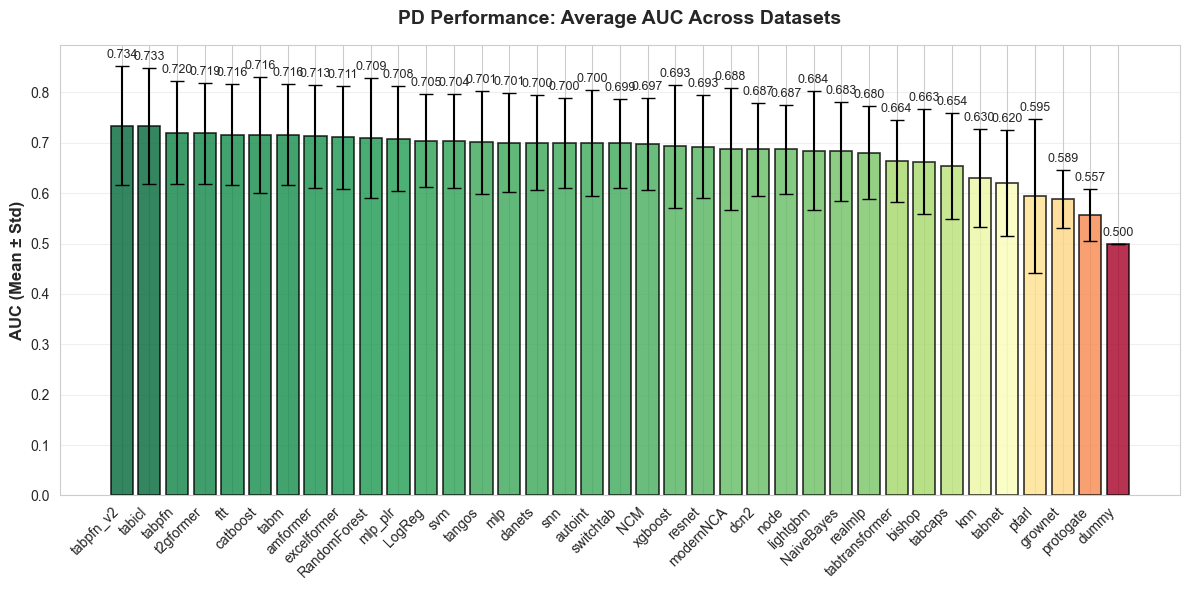

In [29]:
# Bar chart: Average performance across datasets
def plot_average_performance(df, metric, task_name, figsize=(12, 6)):
    """
    Create a bar chart showing average performance across datasets.
    """
    mean_col = f'{metric}_mean'
    std_col = f'{metric}_std'
    
    if mean_col not in df.columns:
        print(f"⚠️  Metric '{metric}' not found")
        return None
    
    # Calculate average across datasets
    method_avg = df.groupby('method')[mean_col].mean().sort_values(ascending=False)
    method_std = df.groupby('method')[mean_col].std()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    x = np.arange(len(method_avg))
    bars = ax.bar(x, method_avg.values, yerr=method_std.loc[method_avg.index].values,
                   capsize=5, alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # Color bars by performance (gradient)
    norm = plt.Normalize(vmin=method_avg.min(), vmax=method_avg.max())
    colors = plt.cm.RdYlGn(norm(method_avg.values))
    for bar, color in zip(bars, colors):
        bar.set_facecolor(color)
    
    ax.set_xticks(x)
    ax.set_xticklabels(method_avg.index, rotation=45, ha='right')
    ax.set_ylabel(f'{metric} (Mean ± Std)', fontsize=12, fontweight='bold')
    ax.set_title(f'{task_name} Performance: Average {metric} Across Datasets',
                 fontsize=14, fontweight='bold', pad=15)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (val, std) in enumerate(zip(method_avg.values, method_std.loc[method_avg.index].values)):
        ax.text(i, val + std + 0.01, f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    filename = FIGURES_DIR / f"{task_name.lower()}_bar_{metric.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {filename.name}")
    
    return fig

# PD: Average AUC
plot_average_performance(pd_agg, 'AUC', 'PD')
plt.show()

✅ Saved: pd_bar_f1.png


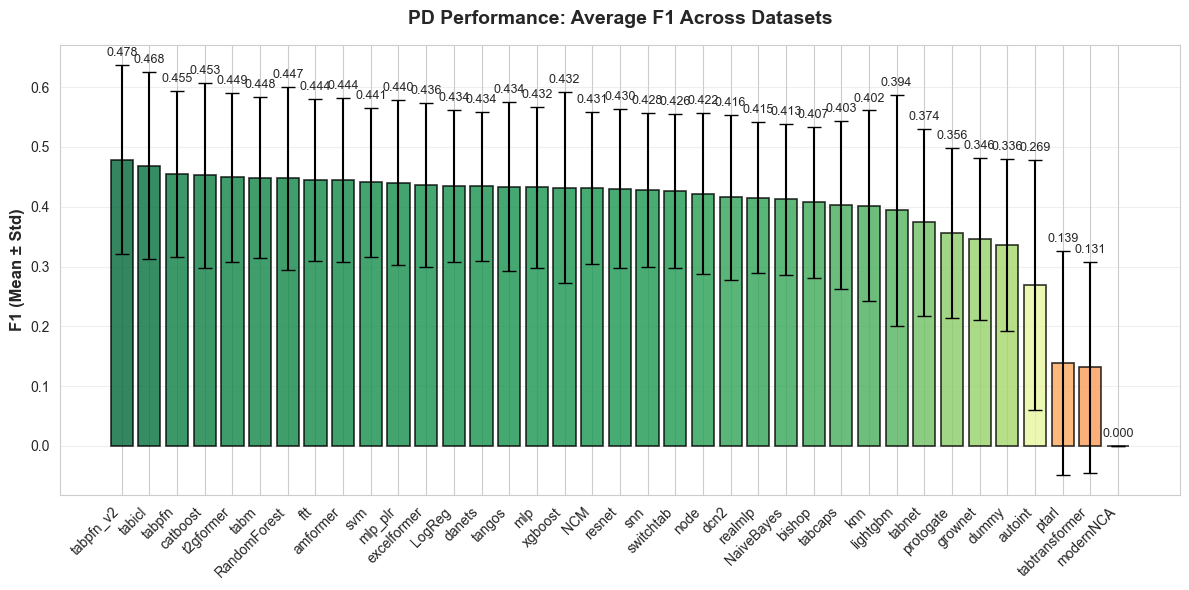

In [30]:
# PD: Average F1
plot_average_performance(pd_agg, 'F1', 'PD')
plt.show()

Creating PD average AUC rank bar chart...
✅ Saved: pd_bar_rank_auc.png


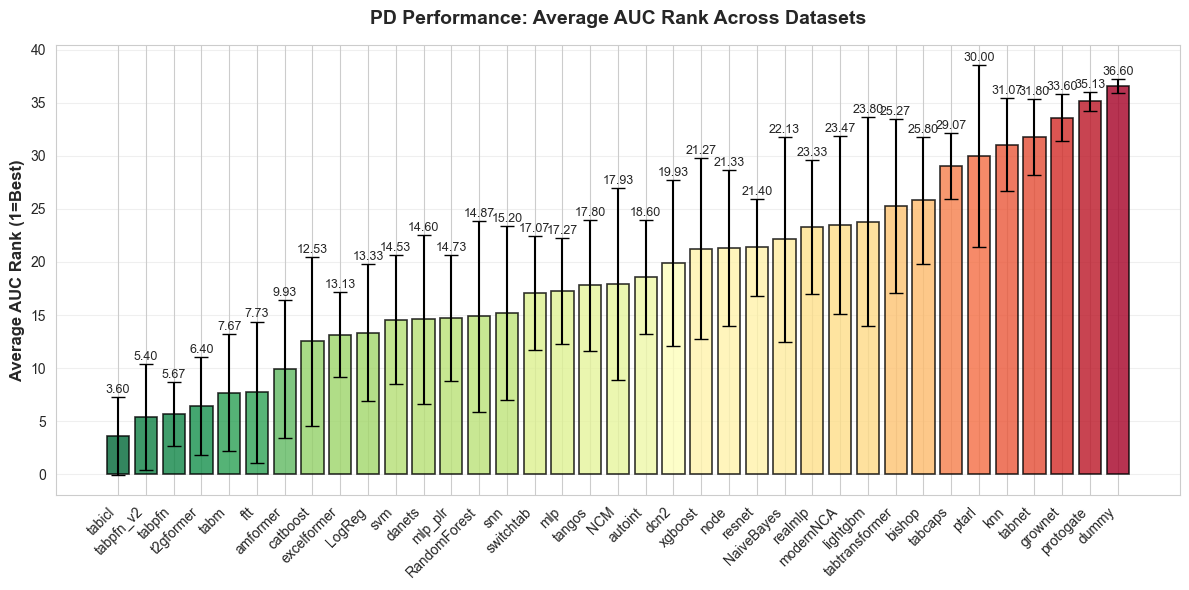


Average AUC Ranks:
method
tabicl             3.600000
tabpfn_v2          5.400000
tabpfn             5.666667
t2gformer          6.400000
tabm               7.666667
ftt                7.733333
amformer           9.933333
catboost          12.533333
excelformer       13.133333
LogReg            13.333333
svm               14.533333
danets            14.600000
mlp_plr           14.733333
RandomForest      14.866667
snn               15.200000
switchtab         17.066667
mlp               17.266667
tangos            17.800000
NCM               17.933333
autoint           18.600000
dcn2              19.933333
xgboost           21.266667
node              21.333333
resnet            21.400000
NaiveBayes        22.133333
realmlp           23.333333
modernNCA         23.466667
lightgbm          23.800000
tabtransformer    25.266667
bishop            25.800000
tabcaps           29.066667
ptarl             30.000000
knn               31.066667
tabnet            31.800000
grownet           33.

In [34]:
def plot_average_rank(df, metric, task_name, figsize=(12, 6)):
    """
    Create a bar chart showing average RANK across datasets.
    
    Lower rank = better performance (Rank 1 = best)
    """
    mean_col = f'{metric}_mean'
    
    if mean_col not in df.columns:
        print(f"⚠️  Metric '{metric}' not found")
        return None
    
    # Create pivot table (datasets × methods)
    pivot = df.pivot(index='dataset', columns='method', values=mean_col)
    
    # Calculate ranks per dataset (row-wise)
    # rank(ascending=False) means higher values get lower ranks (1 = best)
    pivot_ranks = pivot.rank(axis=1, ascending=False, method='min')
    
    # Calculate average rank across datasets
    method_avg_rank = pivot_ranks.mean(axis=0).sort_values(ascending=True)  # Lower is better
    method_std_rank = pivot_ranks.std(axis=0)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    x = np.arange(len(method_avg_rank))
    bars = ax.bar(x, method_avg_rank.values, 
                   yerr=method_std_rank.loc[method_avg_rank.index].values,
                   capsize=5, alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # Color bars by rank (REVERSED: green=low rank=good, red=high rank=bad)
    norm = plt.Normalize(vmin=method_avg_rank.min(), vmax=method_avg_rank.max())
    colors = plt.cm.RdYlGn_r(norm(method_avg_rank.values))  # _r = reversed
    for bar, color in zip(bars, colors):
        bar.set_facecolor(color)
    
    ax.set_xticks(x)
    ax.set_xticklabels(method_avg_rank.index, rotation=45, ha='right')
    ax.set_ylabel(f'Average {metric} Rank (1=Best)', fontsize=12, fontweight='bold')
    ax.set_title(f'{task_name} Performance: Average {metric} Rank Across Datasets',
                 fontsize=14, fontweight='bold', pad=15)
    ax.grid(axis='y', alpha=0.3)
    
    # Invert y-axis so rank 1 appears at top visually (optional)
    # ax.invert_yaxis()  # Uncomment if you want rank 1 at the top
    
    # Add value labels on bars
    for i, (val, std) in enumerate(zip(method_avg_rank.values, 
                                       method_std_rank.loc[method_avg_rank.index].values)):
        ax.text(i, val + std + 0.1, f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    filename = FIGURES_DIR / f"{task_name.lower()}_bar_rank_{metric.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {filename.name}")
    
    return fig, method_avg_rank


# PD: Average AUC Rank
print("Creating PD average AUC rank bar chart...")
fig_pd_rank, ranks_pd = plot_average_rank(pd_agg, 'AUC', 'PD')
plt.show()

# Print the actual ranks
print("\nAverage AUC Ranks:")
print(ranks_pd)

### 3.3 Performance Distribution (PD)

✅ Saved: pd_boxplot_auc.png


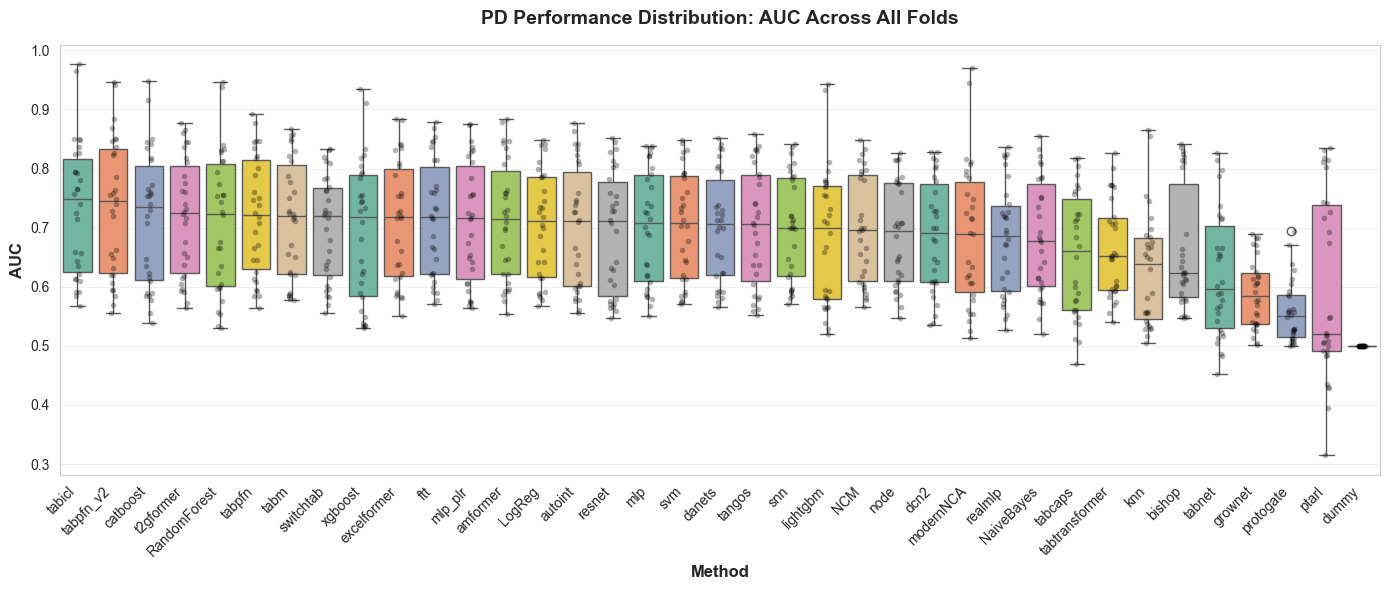

In [31]:
def plot_performance_distribution(df, metric, task_name, figsize=(14, 6)):
    """
    Create boxplot showing distribution of performance across datasets.
    """
    if metric not in df.columns:
        print(f"⚠️  Metric '{metric}' not found")
        return None
    
    # Calculate method order by median performance
    method_order = df.groupby('method')[metric].median().sort_values(ascending=False).index
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create boxplot
    sns.boxplot(
        data=df,
        x='method',
        y=metric,
        order=method_order,
        palette='Set2',
        ax=ax
    )
    
    # Add individual points
    sns.stripplot(
        data=df,
        x='method',
        y=metric,
        order=method_order,
        color='black',
        alpha=0.3,
        size=4,
        ax=ax
    )
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Method', fontsize=12, fontweight='bold')
    ax.set_title(f'{task_name} Performance Distribution: {metric} Across All Folds',
                 fontsize=14, fontweight='bold', pad=15)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    filename = FIGURES_DIR / f"{task_name.lower()}_boxplot_{metric.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {filename.name}")
    
    return fig

# PD: AUC distribution
plot_performance_distribution(pd_raw, 'AUC', 'PD')
plt.show()

✅ Saved: pd_boxplot_f1.png


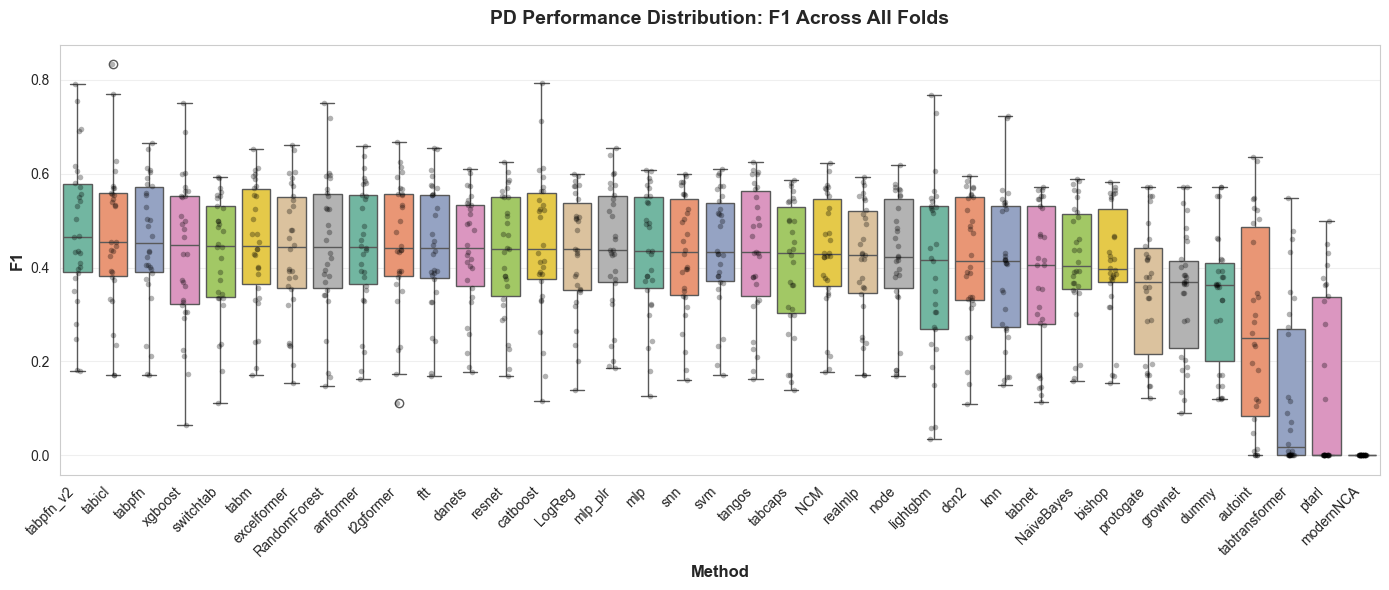

In [32]:
# PD: F1 distribution
plot_performance_distribution(pd_raw, 'F1', 'PD')
plt.show()

## 4. Performance Analysis: LGD Task

### 4.1 Performance Heatmaps (Methods × Datasets)

Creating LGD R2 heatmap...
✅ Saved: lgd_heatmap_r2.png


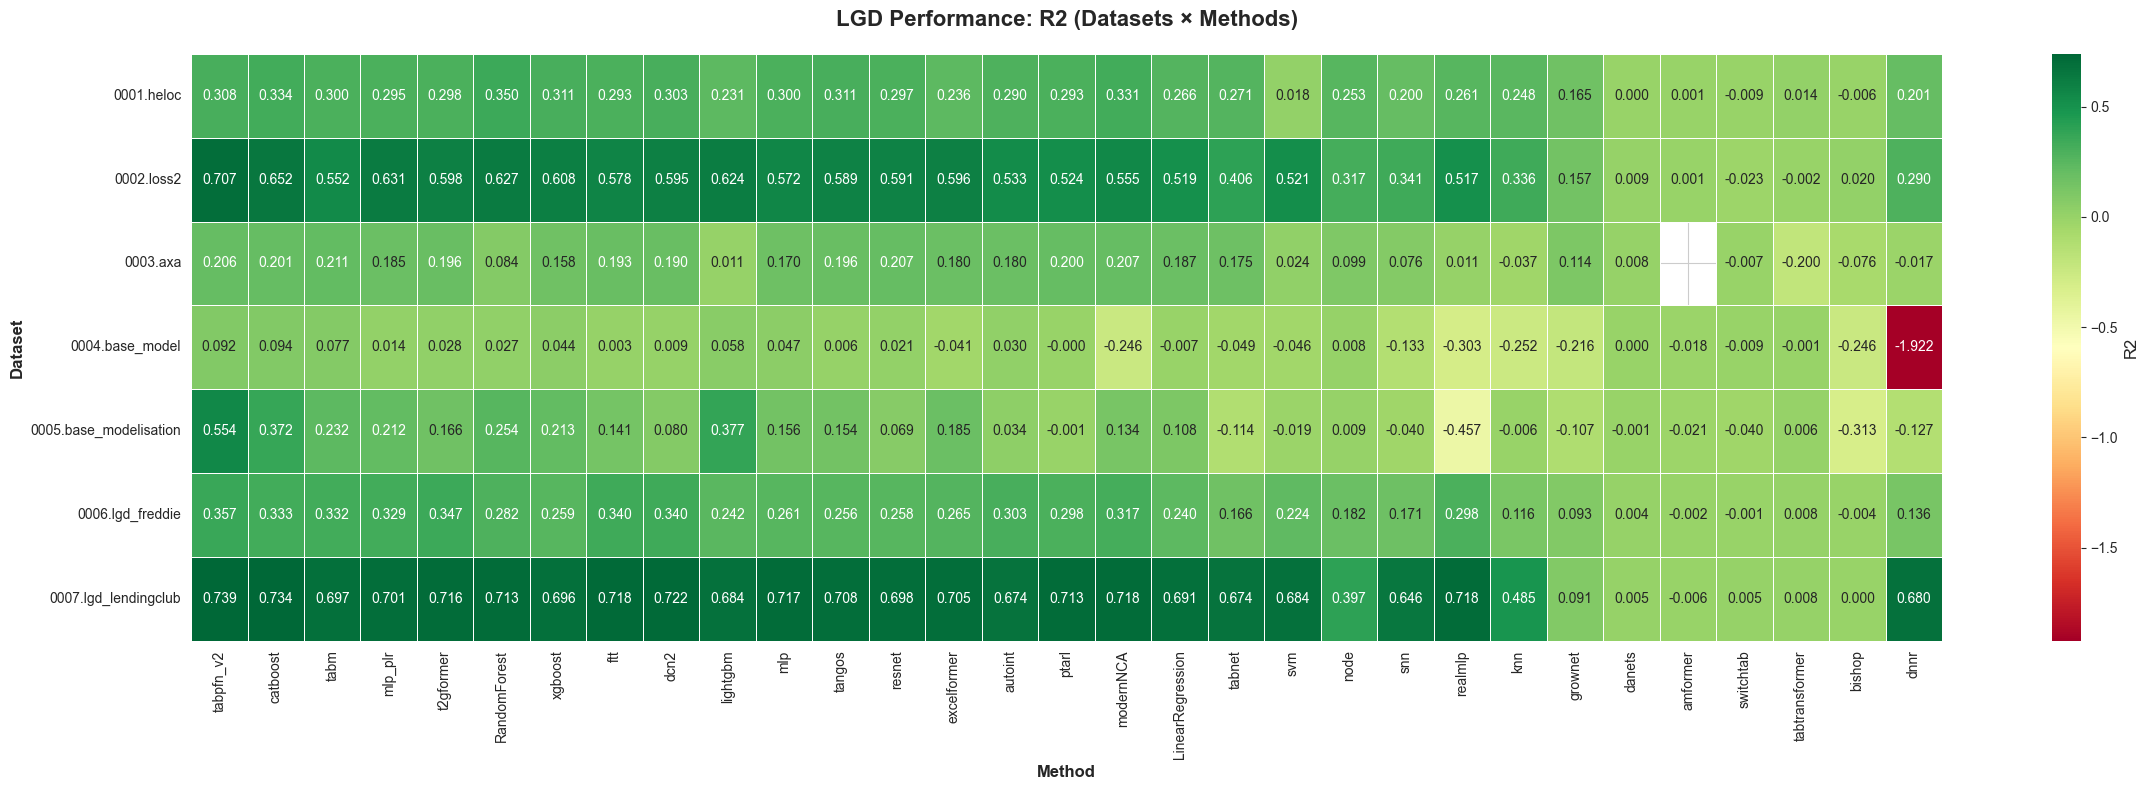

In [35]:
# LGD: R2 Heatmap
print("Creating LGD R2 heatmap...")
fig_lgd_r2, pivot_lgd_r2 = create_performance_heatmap(
    lgd_agg, 'R2', 'LGD', cmap='RdYlGn'
)
plt.show()

Creating LGD R² rank heatmap...
✅ Saved: lgd_heatmap_rank_r2.png


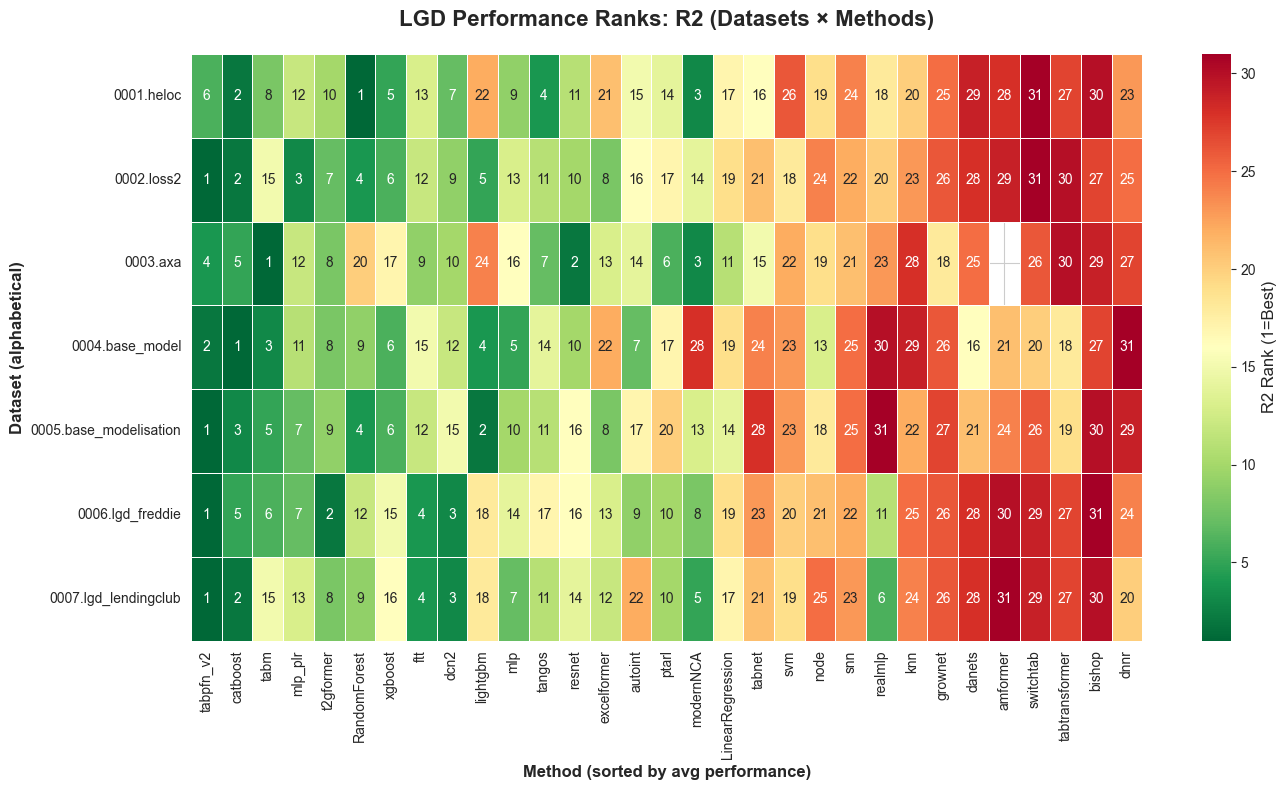

In [37]:
print("Creating LGD R² rank heatmap...")
fig_lgd_r2_rank, pivot_lgd_r2_rank = create_performance_rank_heatmap(
    lgd_agg,      # ← Regression aggregated dataframe
    'R2',         # ← R² metric (not 'R²' - check your column name!)
    'LGD',        # ← Task name
    cmap='RdYlGn_r'
)
plt.show()

### 4.2 Method Rankings (LGD)

In [36]:
# Create LGD rankings
lgd_rankings = create_method_ranking(lgd_agg, ['R2'], 'LGD')


  LGD METHOD RANKINGS (across all datasets)
metric            R2  Avg_Rank
method                        
tabpfn_v2          1       1.0
catboost           2       2.0
tabm               3       3.0
mlp_plr            4       4.0
t2gformer          5       5.0
RandomForest       6       6.0
xgboost            7       7.0
ftt                8       8.0
dcn2               9       9.0
lightgbm          10      10.0
mlp               11      11.0
tangos            12      12.0
resnet            13      13.0
excelformer       14      14.0
autoint           15      15.0
ptarl             16      16.0
modernNCA         17      17.0
LinearRegression  18      18.0
tabnet            19      19.0
svm               20      20.0
node              21      21.0
snn               22      22.0
realmlp           23      23.0
knn               24      24.0
grownet           25      25.0
danets            26      26.0
amformer          27      27.0
switchtab         28      28.0
tabtransformer    29     

✅ Saved: lgd_bar_r2.png


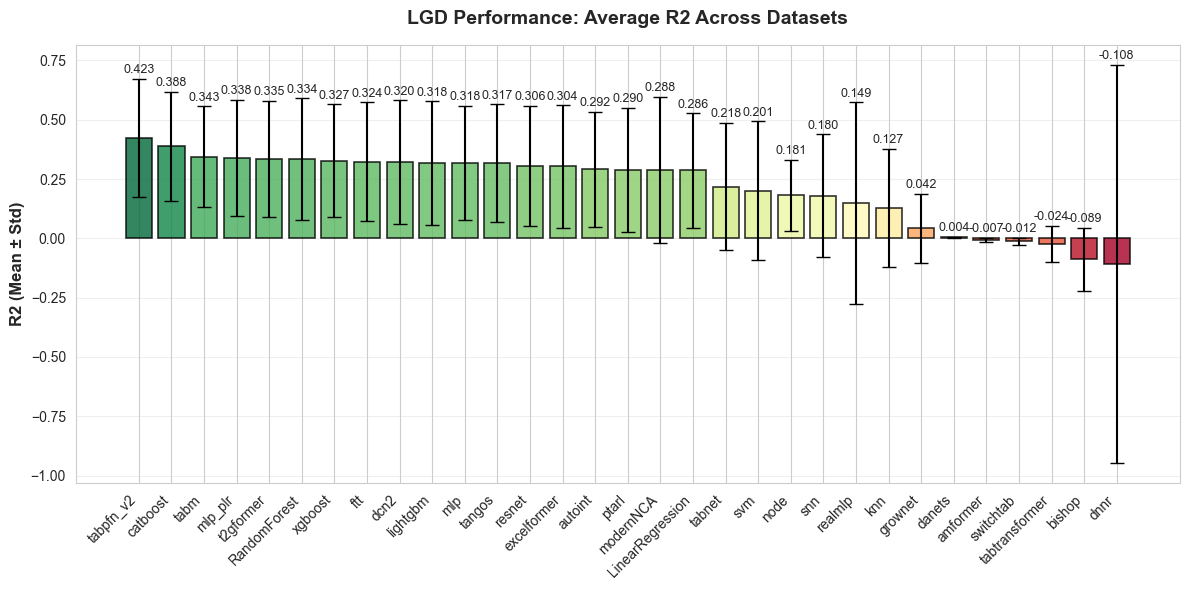

In [14]:
# LGD: Average R2
plot_average_performance(lgd_agg, 'R2', 'LGD')
plt.show()


Creating LGD average R² rank bar chart...
✅ Saved: lgd_bar_rank_r2.png


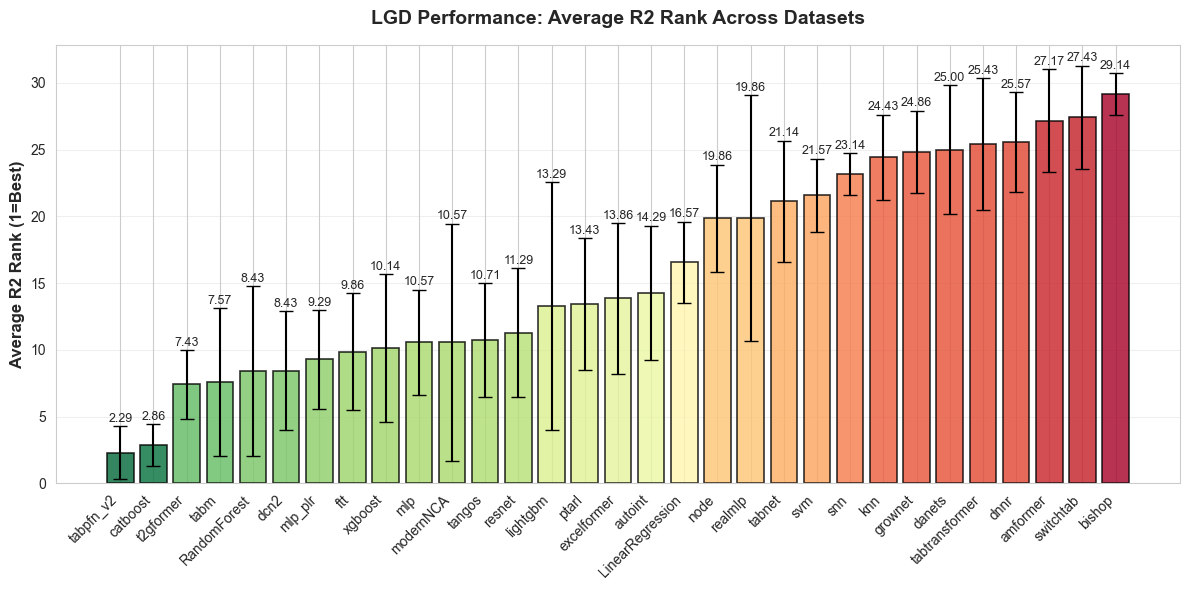


LGD: Average R² Ranks Across Datasets
method
tabpfn_v2            2.285714
catboost             2.857143
t2gformer            7.428571
tabm                 7.571429
RandomForest         8.428571
dcn2                 8.428571
mlp_plr              9.285714
ftt                  9.857143
xgboost             10.142857
mlp                 10.571429
modernNCA           10.571429
tangos              10.714286
resnet              11.285714
lightgbm            13.285714
ptarl               13.428571
excelformer         13.857143
autoint             14.285714
LinearRegression    16.571429
node                19.857143
realmlp             19.857143
tabnet              21.142857
svm                 21.571429
snn                 23.142857
knn                 24.428571
grownet             24.857143
danets              25.000000
tabtransformer      25.428571
dnnr                25.571429
amformer            27.166667
switchtab           27.428571
bishop              29.142857
dtype: float64


In [38]:
print("\nCreating LGD average R² rank bar chart...")
fig_lgd_r2_rank_bar, ranks_lgd_r2 = plot_average_rank(
    lgd_agg,      # ← Regression aggregated dataframe
    'R2',         # ← R² metric
    'LGD'         # ← Task name
)
plt.show()

# Print the actual average ranks
print("\n" + "="*70)
print("LGD: Average R² Ranks Across Datasets")
print("="*70)
print(ranks_lgd_r2)
print("="*70)

### 4.3 Performance Distribution (LGD)

✅ Saved: lgd_boxplot_r2.png


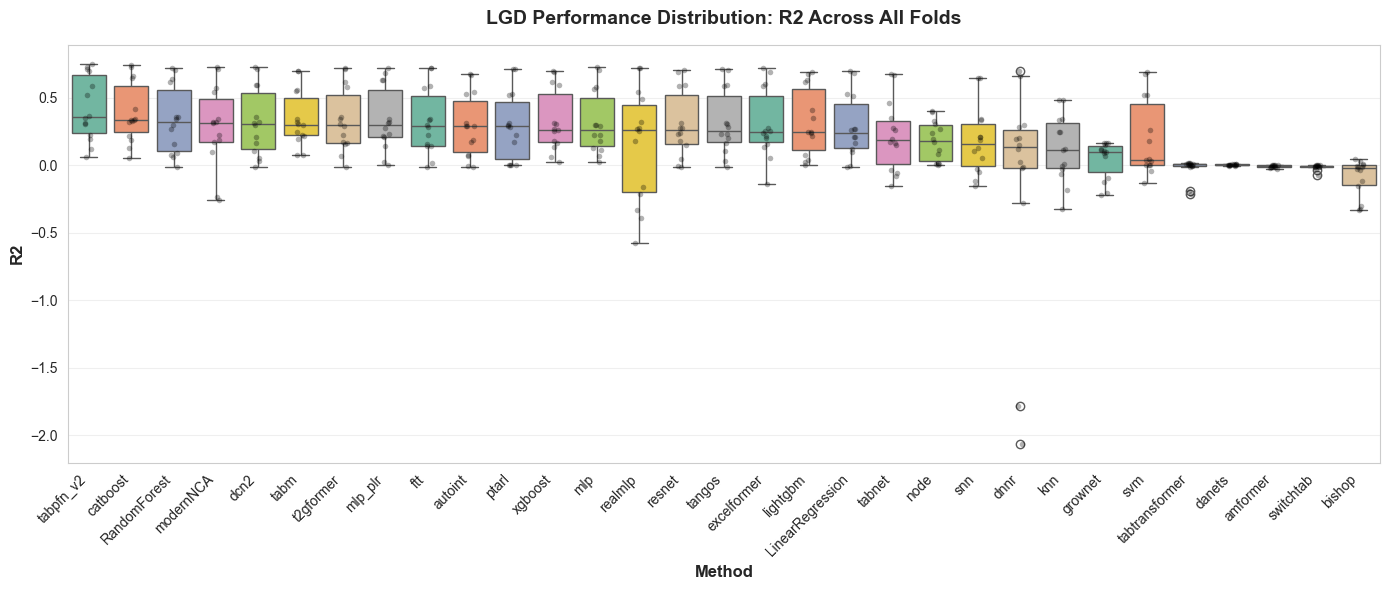

In [15]:
# LGD: R2 distribution
plot_performance_distribution(lgd_raw, 'R2', 'LGD')
plt.show()

## 5. Training Time Analysis

### 5.1 Average Training Time per Method

✅ Saved: training_time_comparison.png


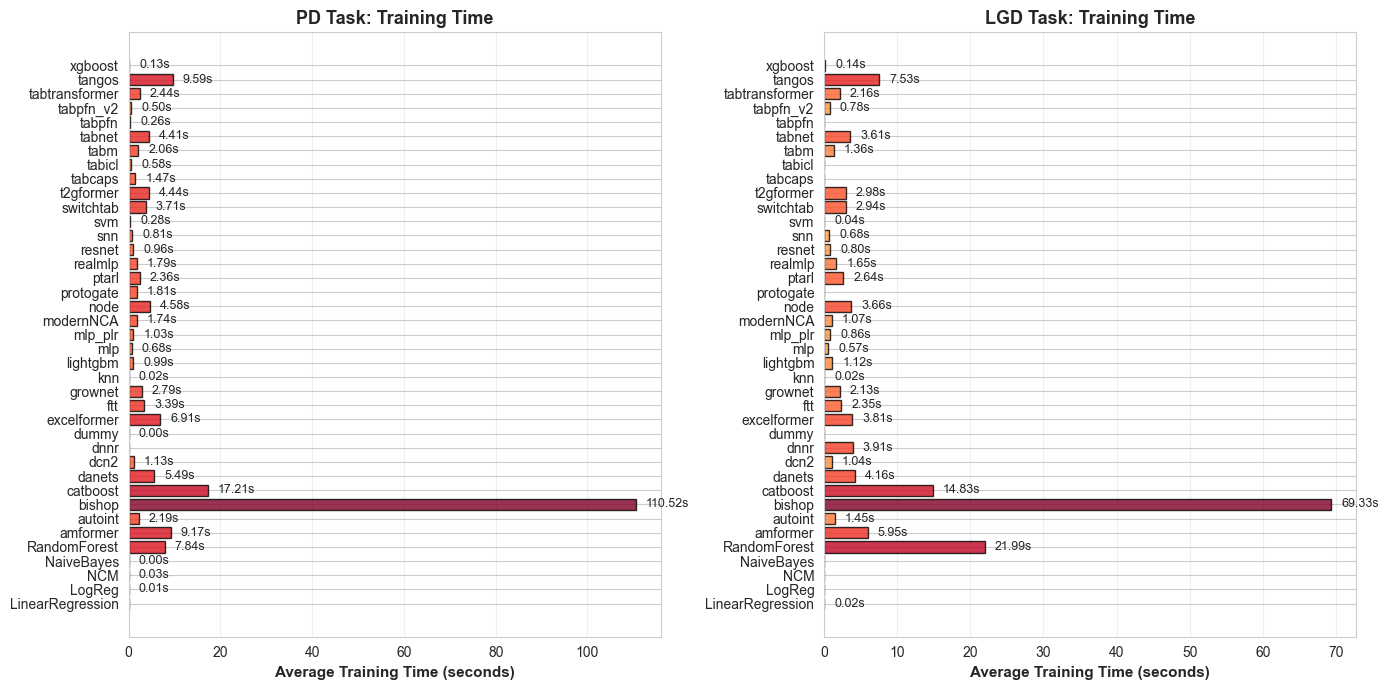

In [16]:
def plot_training_time(df_pd, df_lgd, figsize=(14, 7)):
    """
    Create a bar chart comparing training times across methods.
    """
    # Calculate average training time for each method (across all folds and datasets)
    pd_time = df_pd.groupby('method')['train_time'].mean().sort_values()
    lgd_time = df_lgd.groupby('method')['train_time'].mean().sort_values()
    
    # Combine
    all_methods = sorted(set(pd_time.index) | set(lgd_time.index))
    
    pd_values = [pd_time.get(m, 0) for m in all_methods]
    lgd_values = [lgd_time.get(m, 0) for m in all_methods]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # PD plot
    y_pos = np.arange(len(all_methods))
    bars1 = ax1.barh(y_pos, pd_values, alpha=0.8, edgecolor='black', linewidth=1)
    
    # Color by time (log scale for better visualization)
    norm = plt.Normalize(vmin=np.log10(min([v for v in pd_values if v > 0]) + 1e-6),
                         vmax=np.log10(max(pd_values) + 1e-6))
    colors = plt.cm.YlOrRd(norm(np.log10(np.array(pd_values) + 1e-6)))
    for bar, color in zip(bars1, colors):
        bar.set_facecolor(color)
    
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(all_methods)
    ax1.set_xlabel('Average Training Time (seconds)', fontsize=11, fontweight='bold')
    ax1.set_title('PD Task: Training Time', fontsize=13, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(pd_values):
        if v > 0:
            ax1.text(v + max(pd_values)*0.02, i, f'{v:.2f}s', va='center', fontsize=9)
    
    # LGD plot
    bars2 = ax2.barh(y_pos, lgd_values, alpha=0.8, edgecolor='black', linewidth=1)
    
    norm = plt.Normalize(vmin=np.log10(min([v for v in lgd_values if v > 0]) + 1e-6),
                         vmax=np.log10(max(lgd_values) + 1e-6))
    colors = plt.cm.YlOrRd(norm(np.log10(np.array(lgd_values) + 1e-6)))
    for bar, color in zip(bars2, colors):
        bar.set_facecolor(color)
    
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(all_methods)
    ax2.set_xlabel('Average Training Time (seconds)', fontsize=11, fontweight='bold')
    ax2.set_title('LGD Task: Training Time', fontsize=13, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    for i, v in enumerate(lgd_values):
        if v > 0:
            ax2.text(v + max(lgd_values)*0.02, i, f'{v:.2f}s', va='center', fontsize=9)
    
    plt.tight_layout()
    
    filename = FIGURES_DIR / "training_time_comparison.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {filename.name}")
    
    return fig

plot_training_time(pd_raw, lgd_raw)
plt.show()

### 5.2 Training Time Statistics

In [17]:
# Detailed training time statistics
def training_time_statistics(df_pd, df_lgd):
    """
    Create a comprehensive table of training time statistics.
    """
    stats = []
    
    for task, df in [('PD', df_pd), ('LGD', df_lgd)]:
        for method in df['method'].unique():
            method_df = df[df['method'] == method]['train_time']
            
            stats.append({
                'Task': task,
                'Method': method,
                'Mean (s)': method_df.mean(),
                'Median (s)': method_df.median(),
                'Std (s)': method_df.std(),
                'Min (s)': method_df.min(),
                'Max (s)': method_df.max(),
                'N_Runs': len(method_df)
            })
    
    stats_df = pd.DataFrame(stats)
    
    print("\n" + "="*100)
    print("  TRAINING TIME STATISTICS")
    print("="*100)
    
    for task in ['PD', 'LGD']:
        task_df = stats_df[stats_df['Task'] == task].sort_values('Mean (s)')
        print(f"\n{task} Task:")
        print(task_df.to_string(index=False))
    
    return stats_df

time_stats = training_time_statistics(pd_raw, lgd_raw)


  TRAINING TIME STATISTICS

PD Task:
Task         Method   Mean (s)  Median (s)   Std (s)   Min (s)    Max (s)  N_Runs
  PD          dummy   0.000906    0.000803  0.000598  0.000600   0.004019      30
  PD     NaiveBayes   0.001845    0.001770  0.000597  0.000973   0.003335      30
  PD         LogReg   0.006973    0.005456  0.003966  0.002216   0.014806      30
  PD            knn   0.021593    0.016797  0.034742  0.001877   0.191953      30
  PD            NCM   0.025139    0.021783  0.025483  0.001145   0.102992      30
  PD        xgboost   0.126447    0.151877  0.080368  0.024778   0.328170      30
  PD         tabpfn   0.256020    0.241250  0.282741  0.001926   1.215635      30
  PD            svm   0.283047    0.191374  0.204020  0.043155   0.681219      30
  PD      tabpfn_v2   0.501802    0.458866  0.397073  0.103169   1.863975      30
  PD         tabicl   0.577630    0.589449  0.151743  0.406622   1.048734      30
  PD            mlp   0.675993    0.641656  0.180318  0.2391

### 5.3 Performance vs. Training Time Trade-off

✅ Saved: pd_perf_vs_time_auc.png


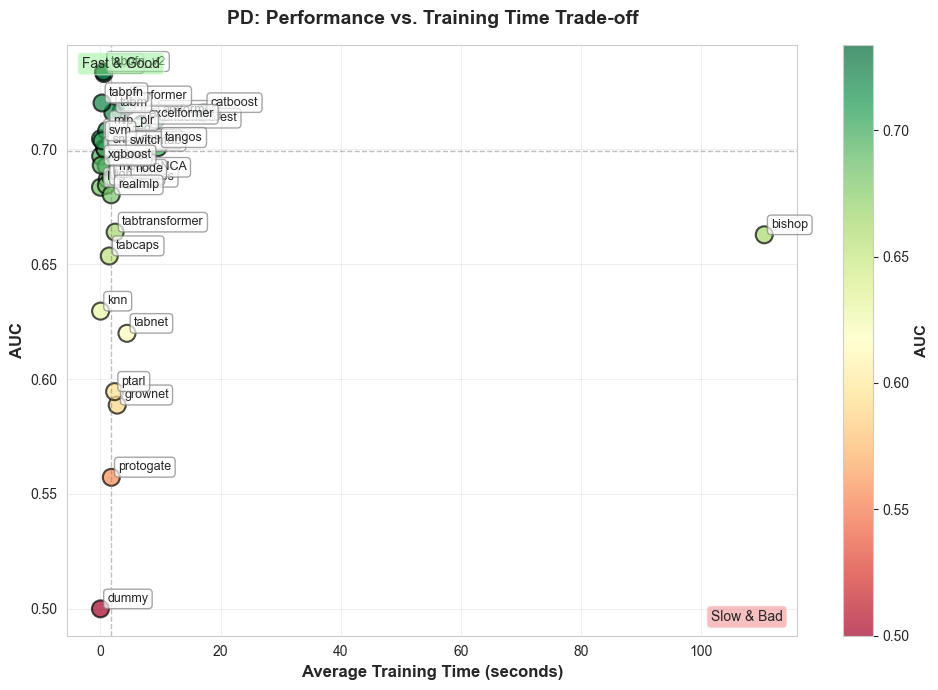

In [18]:
def plot_performance_vs_time(df_raw, df_agg, metric, task_name, figsize=(10, 7)):
    """
    Scatter plot: Performance vs. Training Time.
    """
    mean_col = f'{metric}_mean'
    
    if mean_col not in df_agg.columns:
        print(f"⚠️  Metric '{metric}' not found")
        return None
    
    # Calculate average performance and time per method
    method_perf = df_agg.groupby('method')[mean_col].mean()
    method_time = df_raw.groupby('method')['train_time'].mean()
    
    # Combine
    data = pd.DataFrame({
        'method': method_perf.index,
        'performance': method_perf.values,
        'time': method_time.loc[method_perf.index].values
    })
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create scatter plot
    scatter = ax.scatter(
        data['time'],
        data['performance'],
        s=150,
        alpha=0.7,
        c=data['performance'],
        cmap='RdYlGn',
        edgecolors='black',
        linewidth=1.5
    )
    
    # Add method labels
    for _, row in data.iterrows():
        ax.annotate(
            row['method'],
            (row['time'], row['performance']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='gray')
        )
    
    ax.set_xlabel('Average Training Time (seconds)', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_title(f'{task_name}: Performance vs. Training Time Trade-off',
                 fontsize=14, fontweight='bold', pad=15)
    ax.grid(alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(metric, fontsize=11, fontweight='bold')
    
    # Add quadrant lines (median performance and time)
    ax.axhline(data['performance'].median(), color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(data['time'].median(), color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    # Annotate quadrants
    ax.text(0.02, 0.98, 'Fast & Good', transform=ax.transAxes,
            fontsize=10, va='top', ha='left', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    ax.text(0.98, 0.02, 'Slow & Bad', transform=ax.transAxes,
            fontsize=10, va='bottom', ha='right', bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
    
    plt.tight_layout()
    
    filename = FIGURES_DIR / f"{task_name.lower()}_perf_vs_time_{metric.lower()}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {filename.name}")
    
    return fig, data

# PD: AUC vs Time
fig_pd_tradeoff, data_pd_tradeoff = plot_performance_vs_time(pd_raw, pd_agg, 'AUC', 'PD')
plt.show()

✅ Saved: lgd_perf_vs_time_r2.png


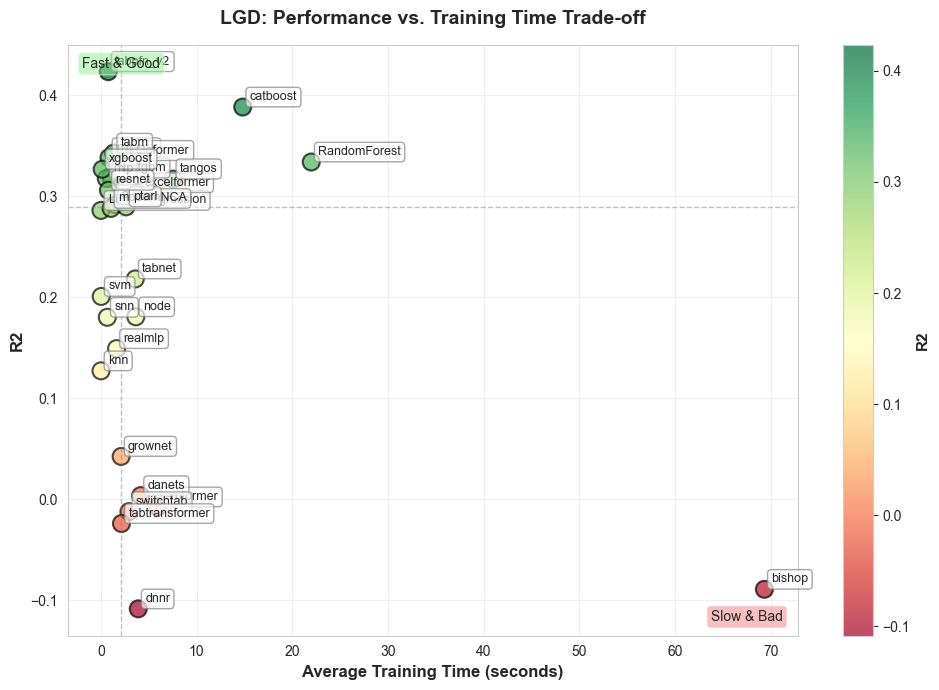

In [19]:
# LGD: R2 vs Time
fig_lgd_tradeoff, data_lgd_tradeoff = plot_performance_vs_time(lgd_raw, lgd_agg, 'R2', 'LGD')
plt.show()

## 7. Final Summary & Recommendations

### 7.1 Executive Summary

In [22]:
print("\n" + "="*100)
print("  EXPERIMENT0 EXECUTIVE SUMMARY")
print("="*100)

print("\n📊 EXPERIMENT OVERVIEW:")
print(f"  - PD Datasets: {pd_raw['dataset'].nunique()}")
print(f"  - LGD Datasets: {lgd_raw['dataset'].nunique()}")
print(f"  - PD Methods Tested: {pd_raw['method'].nunique()}")
print(f"  - LGD Methods Tested: {lgd_raw['method'].nunique()}")
print(f"  - Total Evaluations: {len(pd_raw) + len(lgd_raw)}")

print("\n🏆 TOP 5 METHODS (by average performance):")
print("\n  PD Task (AUC):")
pd_top5 = pd_raw.groupby('method')['AUC'].mean().sort_values(ascending=False).head(5)
for i, (method, score) in enumerate(pd_top5.items(), 1):
    print(f"    {i}. {method:20s} - AUC: {score:.4f}")

print("\n  LGD Task (R2):")
lgd_top5 = lgd_raw.groupby('method')['R2'].mean().sort_values(ascending=False).head(5)
for i, (method, score) in enumerate(lgd_top5.items(), 1):
    print(f"    {i}. {method:20s} - R2: {score:.4f}")

print("\n⚡ FASTEST METHODS (by training time):")
print("\n  PD Task:")
pd_fast5 = pd_raw.groupby('method')['train_time'].mean().sort_values().head(5)
for i, (method, time) in enumerate(pd_fast5.items(), 1):
    print(f"    {i}. {method:20s} - {time:.4f}s")

print("\n  LGD Task:")
lgd_fast5 = lgd_raw.groupby('method')['train_time'].mean().sort_values().head(5)
for i, (method, time) in enumerate(lgd_fast5.items(), 1):
    print(f"    {i}. {method:20s} - {time:.4f}s")

if pd_recommended is not None:
    print(f"\n✅ RECOMMENDED FOR EXPERIMENT1:")
    print(f"\n  PD Methods ({len(pd_recommended)}):")
    for method in pd_recommended['Method']:
        print(f"    - {method}")

if lgd_recommended is not None:
    print(f"\n  LGD Methods ({len(lgd_recommended)}):")
    for method in lgd_recommended['Method']:
        print(f"    - {method}")

print("\n" + "="*100)
print("  📁 All results and figures saved to: " + str(RESULTS_DIR))
print("="*100 + "\n")


  EXPERIMENT0 EXECUTIVE SUMMARY

📊 EXPERIMENT OVERVIEW:
  - PD Datasets: 15
  - LGD Datasets: 7
  - PD Methods Tested: 37
  - LGD Methods Tested: 31
  - Total Evaluations: 1542

🏆 TOP 5 METHODS (by average performance):

  PD Task (AUC):
    1. tabpfn_v2            - AUC: 0.7338
    2. tabicl               - AUC: 0.7329
    3. tabpfn               - AUC: 0.7202
    4. t2gformer            - AUC: 0.7187
    5. ftt                  - AUC: 0.7163

  LGD Task (R2):
    1. tabpfn_v2            - R2: 0.4235
    2. catboost             - R2: 0.3884
    3. tabm                 - R2: 0.3429
    4. mlp_plr              - R2: 0.3384
    5. t2gformer            - R2: 0.3353

⚡ FASTEST METHODS (by training time):

  PD Task:
    1. dummy                - 0.0009s
    2. NaiveBayes           - 0.0018s
    3. LogReg               - 0.0070s
    4. knn                  - 0.0216s
    5. NCM                  - 0.0251s

  LGD Task:
    1. LinearRegression     - 0.0161s
    2. knn                  - 0.0225